# 🩺 Diabetes Prediction using Logistic Regression

## 📌 Project Overview

This project implements a Logistic Regression model to predict whether a patient is diabetic based on several medical features.

---

## 🎯 Objective

To build a binary classification model that predicts whether a patient has diabetes (`Outcome = 1`) or not (`Outcome = 0`).

In [15]:
#Importing Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report 

In [ ]:
#Loading the dataset
df = pd.read_csv("C:/Users/PCM/Documents/AI-ML-Mastery/01-Machine-Learning/Logistic-Regression/Data/diabetes_data.csv")

In [14]:
#Analyzing the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [12]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [13]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


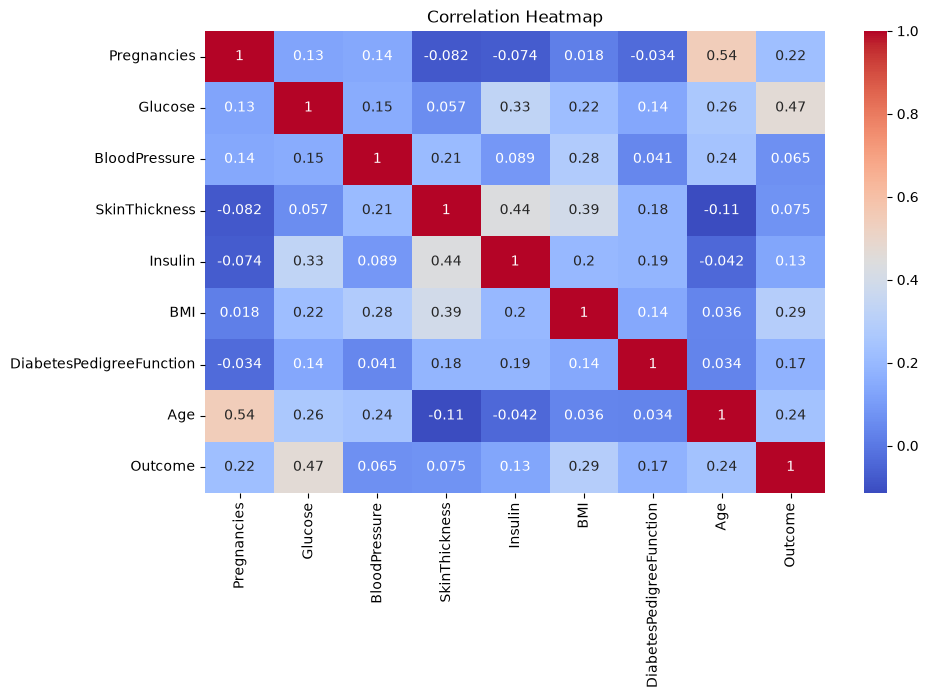

In [20]:
#Visualizing the correlation between features
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')     
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
#Splitting the dataset into features and target variable
x = df.drop('Outcome', axis=1)
y = df['Outcome']

In [17]:
#Splitting the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [18]:
#Standardizing the features
scalar = StandardScaler()
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)

In [ ]:
#Training the Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [23]:
#Making predictions and evaluating the model
y_pred = model.predict(x_test)
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.7532467532467533
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



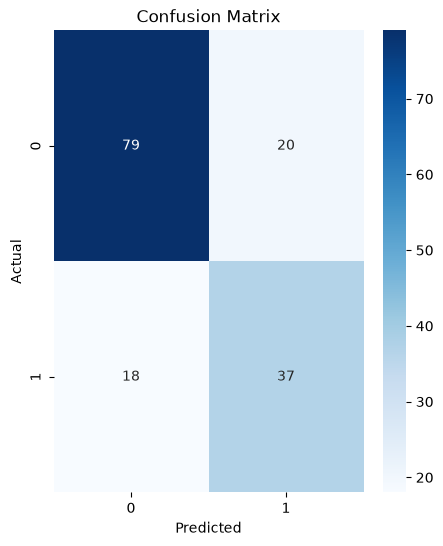

In [25]:
plt.figure(figsize=(5,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')    
plt.show()

In [26]:
data = {
    "Pregnancies":[2],
    "Glucose":[120],
    "BloodPressure":[70],
    "SkinThickness":[20],   
    "Insulin":[79],
    "BMI": [24.5],
    "DiabetesPedigreeFunction": [0.25],
    "Age": [28]
}
sample_df = pd.DataFrame(data)

#Transforming the sample data using the same scaler
sample_scaled = scalar.transform(sample_df)

#Making prediction on the sample data
sample_pred = model.predict(sample_scaled)
sample_prob = model.predict_proba(sample_scaled)

print("Predicted Class:", sample_pred[0])
print("Probability of each class:", sample_prob[0])

Predicted Class: 0
Probability of each class: [0.8922916 0.1077084]


# 🏁 Conclusion

In this project, a **Logistic Regression** model was developed to predict whether a patient has diabetes based on medical attributes such as pregnancies, glucose level, blood pressure, skin thickness, insulin level, BMI, diabetes pedigree function, and age.

The dataset was explored using Exploratory Data Analysis (EDA), followed by feature scaling using **StandardScaler** to improve model performance. The data was then divided into training and testing sets, and a Logistic Regression classifier was trained to perform binary classification.

The model achieved an **accuracy of 75.32%**, demonstrating good performance in classifying diabetic and non-diabetic patients. The Confusion Matrix and Classification Report provided additional insights into the model's strengths and areas where misclassifications occurred.

Finally, the trained model was tested using custom patient data, successfully predicting whether a patient was likely to have diabetes. This project provided hands-on experience with the complete machine learning workflow for a binary classification problem using Logistic Regression.

# 📚 Key Learnings

- Understood the difference between Regression and Classification.
- Learned how Logistic Regression performs binary classification.
- Performed Exploratory Data Analysis (EDA) on a healthcare dataset.
- Applied feature scaling using StandardScaler.
- Split the dataset into training and testing sets.
- Trained and evaluated a Logistic Regression model.
- Evaluated model performance using Accuracy, Confusion Matrix, and Classification Report.
- Predicted diabetes status for new patient data using the trained model.